In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt_default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# Values for "adiabatic" (not really) profile
tau_bot   = 30
omega_top = 0.85
omega_bot = 0.96
g_top     = 0.865
g_bot     = 0.820

In [3]:
omega_func = lambda tau: (
    omega_top + (omega_bot - omega_top) * (tau / tau_bot)   # background
)

g_func = lambda tau: (
    g_top + (g_bot - g_top) * (tau / tau_bot)               # background
)

# --- Spike parameters ---
tau_spike = 0.5 * tau_bot   # location: 50% down the column
sigma     = 0.5              # width in tau units — decrease to sharpen
delta_omega = -0.15          # dip in omega (negative = more absorbing)
delta_g     =  0.04          # bump in g (positive = more forward scattering)

omega_func_drizzle = lambda tau: (
    omega_top + (omega_bot - omega_top) * tau / tau_bot
    + delta_omega * np.exp(-0.5 * ((tau - tau_spike) / sigma) ** 2)
)

g_func_drizzle = lambda tau: (
    g_top + (g_bot - g_top) * tau / tau_bot
    + delta_g * np.exp(-0.5 * ((tau - tau_spike) / sigma) ** 2)
)

In [4]:
tau_plot = np.linspace(0, tau_bot, 300)

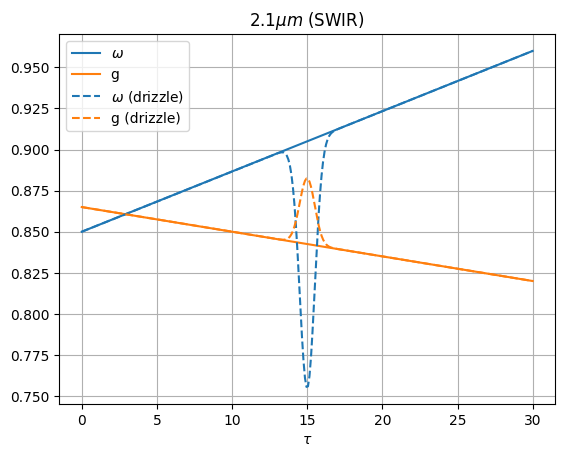

In [5]:
plt.plot(tau_plot, omega_func(tau_plot), label=r"$\omega$", color=plt_default_colors[0])
plt.plot(tau_plot, g_func(tau_plot), label="g", color=plt_default_colors[1])
plt.plot(tau_plot, omega_func_drizzle(tau_plot), "--", label=r"$\omega$ (drizzle)", color=plt_default_colors[0])
plt.plot(tau_plot, g_func_drizzle(tau_plot), "--", label="g (drizzle)", color=plt_default_colors[1])
plt.xlabel(r"$\tau$")
plt.title(r"$2.1\mu m$ (SWIR)")
plt.legend()
plt.grid()

# Call solver

In [6]:
import sys
from pathlib import Path

repo_root = Path.cwd()  # or Path("path/to/repo") if cwd isn't the repo root
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "tests"))

from pydisort_magnus import pydisort_magnus
from _helpers import make_cloud_profile, multilayer_pydisort_toa, assert_convergence, make_D_m_funcs

In [7]:
mu0, I0, phi0 = 0.5, 1.0, 0.0
NQuad = 16
NLeg = NQuad

g_l_func   = lambda tau: g_func(tau) ** np.arange(NLeg)
D_m_funcs  = make_D_m_funcs(g_l_func, NLeg, NQuad)
_, _, _, _, tau_grid = pydisort_magnus(
    tau_bot, omega_func, D_m_funcs, NQuad, mu0, I0, phi0,
    tol=1e-3,
)

g_l_func_drizzle   = lambda tau: g_func_drizzle(tau) ** np.arange(NLeg)
D_m_funcs_drizzle  = make_D_m_funcs(g_l_func_drizzle, NLeg, NQuad)
_, _, _, _, tau_grid_drizzle = pydisort_magnus(
    tau_bot, omega_func_drizzle, D_m_funcs_drizzle, NQuad, mu0, I0, phi0,
    tol=1e-3,
)

In [8]:
len(tau_grid)

39

In [9]:
len(tau_grid_drizzle)

50

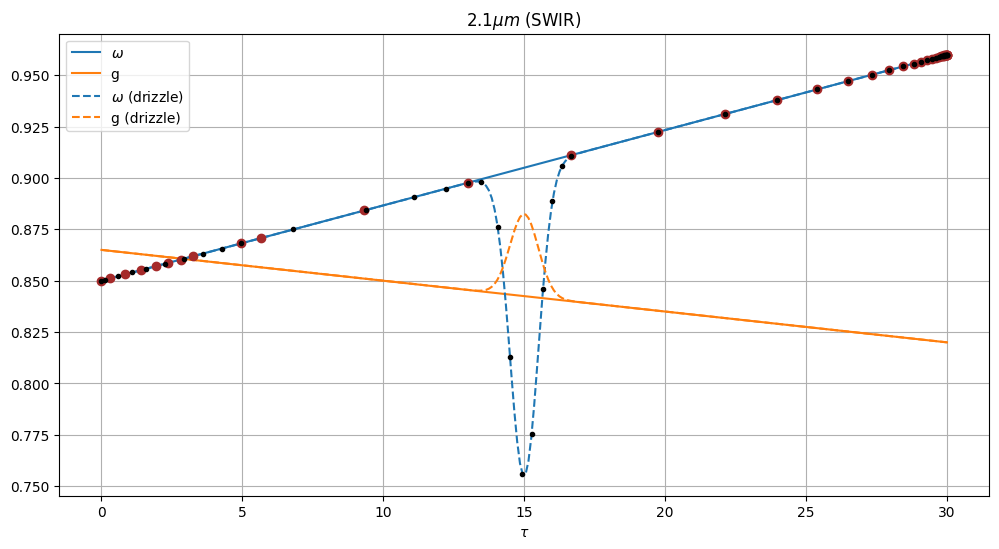

In [10]:
plt.figure(figsize=(12,6))
plt.plot(tau_plot, omega_func(tau_plot), label=r"$\omega$", color=plt_default_colors[0])
plt.plot(tau_plot, g_func(tau_plot), label="g", color=plt_default_colors[1])
plt.plot(tau_plot, omega_func_drizzle(tau_plot), "--", label=r"$\omega$ (drizzle)", color=plt_default_colors[0])
plt.plot(tau_plot, g_func_drizzle(tau_plot), "--", label="g (drizzle)", color=plt_default_colors[1])

plt.plot(tau_grid, omega_func(tau_grid), "o", color="brown")
plt.plot(tau_grid_drizzle, omega_func_drizzle(tau_grid_drizzle), ".", color="black")
plt.xlabel(r"$\tau$")
plt.title(r"$2.1\mu m$ (SWIR)")
plt.legend()
plt.grid()